# Aula 8 — Modelos de Ordem Reduzida e Consolidação do Módulo 1
### Projeção em subespaços de baixa dimensão, Galerkin–POD conceitual e síntese SVD–PCA–POD

**Professor:** Prof. Dr. Rodrigo Figueiredo Abdo

*Curso: Fundamentos de Aprendizado de Máquina Científico para Mecânica dos Fluidos*

## Descrição

Este notebook **complementa** as notas da Aula 8 e fecha o Módulo 1. Até aqui aprendemos a
**reduzir dados** (SVD, PCA, POD). Agora damos um passo a mais: **reduzir a dinâmica**. Um modelo
de ordem reduzida (ROM) aproxima o estado por $\mathbf{u}\approx\Phi\mathbf{a}$ e obtém equações
para os poucos coeficientes $\mathbf{a}(t)$ pela **projeção de Galerkin**:
$\dot{\mathbf{a}}=\Phi^T\mathbf{F}(\Phi\mathbf{a})$.

Vamos projetar estados, construir o operador reduzido $A_r=\Phi^TA\Phi$, montar um **ROM completo**
(offline POD + online integração) e compará-lo ao sistema de alta dimensão, discutir a equação do
calor em base modal, a diferença entre POD e ROM, e consolidar SVD/PCA/POD/ROM.

## Requisitos

| Biblioteca | Versão mínima | Finalidade |
|---|---|---|
| `numpy` | 1.22 | álgebra linear, projeções, POD |
| `scipy` | 1.8 | `solve_ivp` (integração temporal do ROM e do sistema completo) — dependência direta |
| `matplotlib` | 3.5 | campos, curvas de erro, decaimento modal |

```bash
pip install numpy scipy matplotlib
```

In [1]:
# --- Imports concentrados ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Mais adiante (Seção 8) sorteamos um vetor aleatório só para ilustrar o custo do
# termo não linear. Fixar a semente faz esse sorteio dar SEMPRE o mesmo resultado,
# para que o notebook seja reprodutível (você vê os mesmos números a cada execução).
np.random.seed(42)

# Vamos integrar VÁRIOS sistemas lineares dy/dt = M y (o completo e o reduzido).
# Para não repetir a mesma chamada toda vez, juntamos a integração numa função.
# Quem faz o trabalho pesado é o solve_ivp do scipy, um integrador pronto e estável:
# nós NÃO programamos nenhum passo de tempo à mão.
def integra_linear(M, y0, t):
    '''Integra dy/dt = M y com solve_ivp; retorna a solução (dim, len(t)).'''
    # solve_ivp pede a derivada como uma FUNÇÃO de (tempo, estado). Como o lado
    # direito aqui é M @ y, escrevemos essa regra com um "lambda" (função anônima
    # curta): lambda tt, y: M @ y. O 'tt' é o tempo (não usado, pois M é constante).
    # (t[0], t[-1]) é o intervalo de tempo; t_eval=t pede a solução nesses instantes;
    # rtol/atol são as tolerâncias de precisão do integrador.
    sol = solve_ivp(lambda tt, y: M @ y, (t[0], t[-1]), y0, t_eval=t, rtol=1e-8, atol=1e-10)
    return sol.y                          # matriz (dim, len(t)): cada coluna é o estado num instante

print("Ambiente pronto.")

Ambiente pronto.


## Objetivos computacionais

1. Projetar estados ($\mathbf{a}=\Phi^T\mathbf{u}$, $\mathbf{u}_r=\Phi\Phi^T\mathbf{u}$) e verificar
   erro **ortogonal**.
2. Construir o operador reduzido $A_r=\Phi^TA\Phi$ (Exemplos 1–2).
3. Montar um **ROM Galerkin–POD** completo e compará-lo ao sistema de alta dimensão.
4. Verificar a equação do **calor** em base modal e a distinção **POD ≠ ROM**.
5. Discutir o gargalo **não linear** e consolidar **SVD/PCA/POD/ROM**.

## 1. Projeção no subespaço e erro ortogonal (Exemplo 1)

$\mathbf{a}=\Phi^T\mathbf{u}$, $\mathbf{u}_r=\Phi\Phi^T\mathbf{u}$, $\mathbf{e}=\mathbf{u}-\mathbf{u}_r$
com $\Phi^T\mathbf{e}=0$. Reproduzimos o Exemplo 1: $\mathbf{u}=(2,4,3)\Rightarrow
\mathbf{a}=(3\sqrt2,3)$, $\mathbf{u}_r=(3,3,3)$.

In [2]:
# Exemplo 1: projeção e ortogonalidade do erro.
# phi1 e phi2 são os dois modos (direções) que geram o subespaço. Cada um já vem
# normalizado: phi1 é dividido por sqrt(2) para ter comprimento 1.
phi1 = np.array([1, 1, 0.0]) / np.sqrt(2)
phi2 = np.array([0, 0, 1.0])

# np.column_stack empilha os vetores como COLUNAS de uma matriz: Phi fica 3x2,
# com phi1 na 1a coluna e phi2 na 2a. É assim que montamos a base Phi das notas.
Phi = np.column_stack([phi1, phi2])
# Modos ortonormais => Phi^T Phi = I (identidade). np.eye(2) é a identidade 2x2.
print("Phi^T Phi = I ?", np.allclose(Phi.T @ Phi, np.eye(2)))

u = np.array([2.0, 4.0, 3.0])
a = Phi.T @ u                      # coordenadas reduzidas: a = Phi^T u (projeta u na base)
u_r = Phi @ a                      # reconstrução projetada: u_r = Phi a (volta para R^3)
e = u - u_r                        # erro de projeção: o que o subespaço não consegue representar
print("a =", np.round(a, 4), "(esperado 3*sqrt(2)=", round(3*np.sqrt(2),4), ", 3)")
print("u_r =", u_r, "(esperado [3,3,3])")
# Phi^T e deve dar zero: o erro é ortogonal ao subespaço (ponte para Galerkin).
print("e =", e, "| Phi^T e =", np.round(Phi.T @ e, 12), "(ortogonal ao subespaço)")

Phi^T Phi = I ? True
a = [4.2426 3.    ] (esperado 3*sqrt(2)= 4.2426 , 3)
u_r = [3. 3. 3.] (esperado [3,3,3])
e = [-1.  1.  0.] | Phi^T e = [0. 0.] (ortogonal ao subespaço)


## 2. Operador reduzido linear $A_r=\Phi^TA\Phi$ (Exemplo 2)

Para $A=\operatorname{diag}(-1,-2,-10)$ e o $\Phi$ acima, espera-se
$A_r=\operatorname{diag}(-3/2,-10)$.

In [3]:
# Exemplo 2: projeção de um sistema linear.
# np.diag([...]) cria a matriz diagonal com esses valores na diagonal (zeros fora).
A = np.diag([-1.0, -2.0, -10.0])
# Operador reduzido: A_r = Phi^T A Phi. Sai uma matriz pequena 2x2 a partir da 3x3.
# Os "@" encadeados fazem as duas multiplicações em sequência: (Phi^T A) e depois (... Phi).
A_r = Phi.T @ A @ Phi
print("A_r =\n", np.round(A_r, 6), "\n(esperado diag(-1.5, -10))")

A_r =
 [[ -1.5   0. ]
 [  0.  -10. ]] 
(esperado diag(-1.5, -10))


## 3. ROM completo — etapa *offline*: equação do calor + POD

Discretizamos a equação do calor 1D $\partial_t u=\alpha\,\partial_{xx}u$ (Dirichlet homogêneo) por
diferenças finitas, gerando $\dot{\mathbf{u}}=A\mathbf{u}$ com $A$ = Laplaciano. Integramos o
**sistema completo** a partir de uma condição inicial, coletamos snapshots e fazemos **POD**.

In [4]:
# Discretização da equação do calor 1D.
n = 100; L = 1.0; alpha = 0.5
# Malha com n+2 pontos de 0 a L; o fatiamento [1:-1] descarta o primeiro e o último
# (as bordas x=0 e x=L, onde u=0 por Dirichlet), deixando só os n pontos INTERIORES.
x = np.linspace(0, L, n+2)[1:-1]      # pontos interiores (Dirichlet em 0 e L)
dx = x[1] - x[0]                      # espaçamento entre pontos vizinhos

# Laplaciano 1D pela "segunda diferença" (u_{i-1} - 2 u_i + u_{i+1}) / dx^2.
# Montamos a matriz somando três diagonais com np.diag:
#   np.diag(v)      -> coloca o vetor v na diagonal principal;
#   np.diag(v, 1)   -> coloca v na diagonal logo ACIMA (vizinho da direita);
#   np.diag(v, -1)  -> coloca v na diagonal logo ABAIXO (vizinho da esquerda).
# As diagonais vizinhas têm n-1 entradas (uma a menos que a principal).
D2 = (np.diag(-2*np.ones(n)) + np.diag(np.ones(n-1), 1) + np.diag(np.ones(n-1), -1)) / dx**2
A = alpha * D2                        # operador da equação: du/dt = A u

# Condição inicial: combinação de senos (suave). np.sin atua componente a componente em x.
u0 = np.sin(np.pi*x) + 0.5*np.sin(3*np.pi*x) + 0.3*np.sin(5*np.pi*x)
t = np.linspace(0, 0.2, 60)
U_full = integra_linear(A, u0, t)     # (n, len(t)) sistema completo: cada coluna é u(t_k)

# POD dos snapshots (sem média: o campo decai a zero). A POD é a SVD da matriz de snapshots.
# full_matrices=False devolve só as partes úteis (mais econômico). Uu tem os MODOS
# espaciais nas colunas; s são os valores singulares (importância de cada modo).
Uu, s, Vt = np.linalg.svd(U_full, full_matrices=False)
# Energia = sigma^2. np.cumsum faz a SOMA ACUMULADA (1o, 1o+2o, 1o+2o+3o, ...);
# dividir pela soma total dá a fração de energia capturada pelos primeiros modos.
energia = np.cumsum(s**2)/np.sum(s**2)
print("4 maiores sigma:", np.round(s[:4], 4))
print("energia acumulada (1..4 modos):", np.round(energia[:4], 5))

4 maiores sigma: [36.7544  5.767   1.0862  0.    ]
energia acumulada (1..4 modos): [0.97514 0.99915 1.      1.     ]


## 4. ROM — etapa *online*: integrar $\dot{\mathbf{a}}=A_r\mathbf{a}$

Com $\Phi=$ primeiros $r$ modos POD, montamos $A_r=\Phi^TA\Phi$, integramos o sistema **reduzido**
($r$ EDOs) a partir de $\mathbf{a}_0=\Phi^T\mathbf{u}_0$ e reconstruímos $\mathbf{u}_r=\Phi\mathbf{a}$.

ROM com r=3: erro global E_F = 3.92e-09


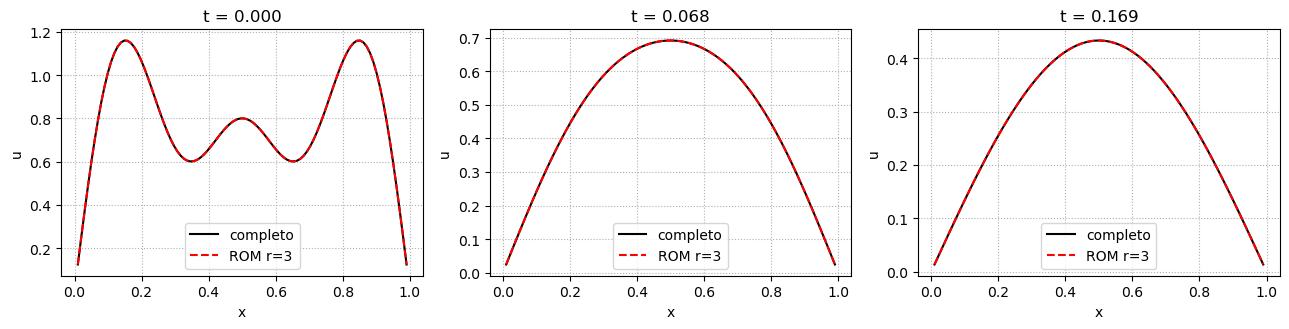

In [5]:
# ROM com r modos: integra reduzido e compara ao completo.
# Vamos repetir o ROM para vários valores de r; por isso juntamos os passos numa função.
def roda_rom(r):
    Phi = Uu[:, :r]                       # primeiros r modos POD (as r primeiras colunas de Uu)
    A_r = Phi.T @ A @ Phi                 # operador reduzido r x r
    a0 = Phi.T @ u0                       # condição inicial projetada no subespaço
    a_t = integra_linear(A_r, a0, t)      # integra as r EDOs reduzidas -> (r, len(t))
    return Phi @ a_t                      # reconstrói o campo completo: u_r = Phi a -> (n, len(t))

r = 3
U_rom = roda_rom(r)
# Erro global E_F: norma de Frobenius (tamanho da matriz inteira) da diferença,
# dividida pela norma do campo completo -> erro RELATIVO entre 0 e 1.
erro_F = np.linalg.norm(U_full - U_rom, 'fro') / np.linalg.norm(U_full, 'fro')
print(f"ROM com r={r}: erro global E_F = {erro_F:.2e}")

# Comparar perfis em alguns instantes. Escolhemos 3 índices de tempo: 0, 20 e 50.
# zip(axes, [0, 20, 50]) percorre, em paralelo, cada painel 'ax' e o índice 'k'
# correspondente: 1o painel <-> k=0, 2o painel <-> k=20, 3o painel <-> k=50.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, k in zip(axes, [0, 20, 50]):
    ax.plot(x, U_full[:, k], "k-", label="completo")       # campo completo no instante k
    ax.plot(x, U_rom[:, k], "r--", label=f"ROM r={r}")     # campo do ROM no mesmo instante
    ax.set_title(f"t = {t[k]:.3f}"); ax.set_xlabel("x"); ax.set_ylabel("u"); ax.legend(); ax.grid(True, ls=":")
plt.tight_layout(); plt.show()

## 5. Erro do ROM em função do número de modos $r$

Mais modos ⇒ subespaço mais rico ⇒ menor erro (até a precisão da integração).

r=1: E_F = 1.60e-01
r=2: E_F = 3.05e-02
r=3: E_F = 3.92e-09
r=4: E_F = 4.06e-09
r=5: E_F = 4.12e-09
r=6: E_F = 4.09e-09
r=7: E_F = 4.10e-09
r=8: E_F = 4.11e-09


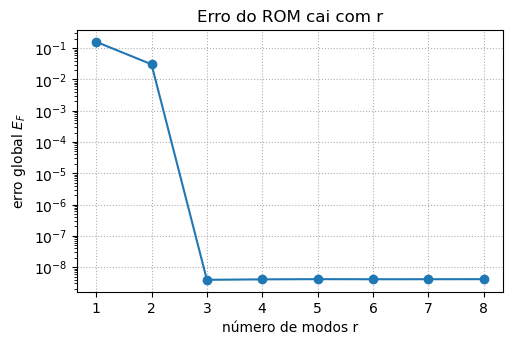

In [6]:
# Erro global do ROM variando r.
rs = range(1, 9)                          # valores de r a testar: 1, 2, ..., 8
# "List comprehension": uma forma compacta de montar uma lista. A linha abaixo lê-se
# "para cada r em rs, calcule o erro relativo do ROM e guarde na lista 'erros'".
# É o mesmo que um for que vai dando append, só que escrito em uma linha.
erros = [np.linalg.norm(U_full - roda_rom(r), 'fro')/np.linalg.norm(U_full, 'fro') for r in rs]

# zip(rs, erros) emparelha cada r com seu erro, para imprimir os dois juntos.
for r, er in zip(rs, erros):
    print(f"r={r}: E_F = {er:.2e}")

# Gráfico em escala log no eixo y (semilogy): o erro cai ordens de grandeza,
# então a escala logarítmica deixa a queda visível.
fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.semilogy(list(rs), erros, "o-")
ax.set_xlabel("número de modos r"); ax.set_ylabel(r"erro global $E_F$")
ax.set_title("Erro do ROM cai com r"); ax.grid(True, ls=":"); plt.show()

## 6. Equação do calor em base modal (Seção 8)

Com os modos seno $\phi_j=\sqrt{2/L}\sin(j\pi x/L)$, a projeção dá $A_r$ **diagonal** com
entradas $-\alpha(j\pi/L)^2$, e os coeficientes **desacoplam**: $a_j(t)=a_j(0)e^{-\alpha(j\pi/L)^2 t}$.

In [7]:
# Modos seno analíticos e operador reduzido (deve ser ~ diagonal).
# Cada modo j é o seno phi_j(x) = sqrt(2/L) sin(j pi x / L), avaliado na malha x.
def modo_seno(j):
    phi = np.sqrt(2/L) * np.sin(j*np.pi*x/L)
    return phi / np.linalg.norm(phi)      # normaliza no produto interno discreto (comprimento 1)

rmod = 4
# Montamos Phi_sin com os modos j = 1, 2, 3, 4 como colunas. A comprehension
# [modo_seno(j) for j in range(1, rmod+1)] gera a lista [phi_1, phi_2, phi_3, phi_4]
# e np.column_stack a transforma numa matriz (cada phi_j vira uma coluna).
Phi_sin = np.column_stack([modo_seno(j) for j in range(1, rmod+1)])
A_r_sin = Phi_sin.T @ A @ Phi_sin         # operador reduzido na base seno
print("A_r (base seno), arredondado:\n", np.round(A_r_sin, 2))
# np.diag(M) extrai a DIAGONAL de M como vetor (note: np.diag faz as duas coisas,
# dependendo de receber vetor ou matriz). Aqui esperamos -alpha (j pi / L)^2.
print("\ndiagonal de A_r:", np.round(np.diag(A_r_sin), 3))
print("esperado -alpha(j*pi/L)^2:", np.round([-alpha*(j*np.pi/L)**2 for j in range(1, rmod+1)], 3))
# np.diag(np.diag(A_r_sin)) reconstrói uma matriz SÓ com a diagonal (zera o resto);
# comparar com A_r_sin testa se a matriz é (quase) diagonal -> modos desacoplados.
print("A_r é (quase) diagonal?", np.allclose(A_r_sin, np.diag(np.diag(A_r_sin)), atol=1e-6))

A_r (base seno), arredondado:
 [[ -4.93  -0.     0.     0.  ]
 [ -0.   -19.73  -0.     0.  ]
 [  0.    -0.   -44.38   0.  ]
 [ -0.     0.     0.   -78.86]]

diagonal de A_r: [ -4.934 -19.733 -44.381 -78.855]
esperado -alpha(j*pi/L)^2: [ -4.935 -19.739 -44.413 -78.957]
A_r é (quase) diagonal? True


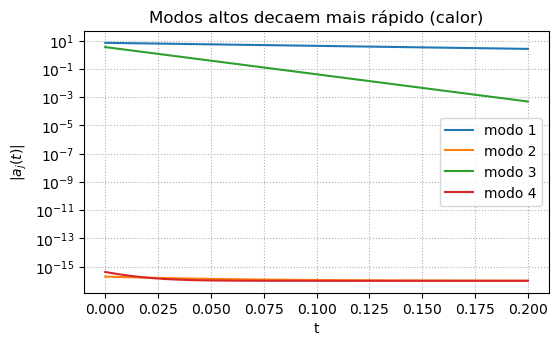

In [8]:
# Decaimento exponencial dos coeficientes modais.
a0 = Phi_sin.T @ u0                        # projeta a condição inicial na base seno
# Integramos só com a parte diagonal de A_r (np.diag(np.diag(...)) zera os termos fora
# da diagonal): assim cada coeficiente a_j evolui SOZINHO, sem se misturar com os outros.
a_t = integra_linear(np.diag(np.diag(A_r_sin)), a0, t)
fig, ax = plt.subplots(figsize=(6, 3.4))
# Uma curva por modo. a_t[j] é a linha j (o coeficiente do modo j+1 ao longo do tempo).
# Somamos 1e-16 só para evitar log(0) na escala semilog (não muda o gráfico visível).
for j in range(rmod):
    ax.semilogy(t, np.abs(a_t[j]) + 1e-16, label=f"modo {j+1}")
ax.set_xlabel("t"); ax.set_ylabel(r"$|a_j(t)|$"); ax.legend(); ax.grid(True, ls=":")
ax.set_title("Modos altos decaem mais rápido (calor)"); plt.show()

## 7. POD não é automaticamente ROM

A POD dá a melhor **reconstrução** dos snapshots (projeção). O ROM tenta **prever** a dinâmica.
Comparamos o erro de **projeção** (limite inferior, usando o estado verdadeiro) com o erro do
**ROM** (que só conhece a condição inicial e integra no subespaço).

In [9]:
# Erro de projeção (conhece u(t)) vs erro do ROM (só integra a0).
def erro_projecao(r):
    Phi = Uu[:, :r]
    # Projeta CADA snapshot verdadeiro no subespaço: U_proj = Phi (Phi^T U_full).
    # Isso usa o estado real u(t) em todo instante -> a melhor reconstrução possível
    # no subespaço (limite inferior de erro, que nenhum ROM consegue bater).
    U_proj = Phi @ (Phi.T @ U_full)
    return np.linalg.norm(U_full - U_proj, 'fro')/np.linalg.norm(U_full, 'fro')

for r in [1, 2, 3, 4]:
    ep = erro_projecao(r)                  # erro de projeção (usa o estado verdadeiro)
    er = np.linalg.norm(U_full - roda_rom(r), 'fro')/np.linalg.norm(U_full, 'fro')  # erro do ROM
    print(f"r={r}: erro projeção = {ep:.2e} | erro ROM = {er:.2e}")
print("\nO erro do ROM nunca é menor que o de projeção: a dinâmica reduzida é uma aproximação a mais.")

r=1: erro projeção = 1.58e-01 | erro ROM = 1.60e-01
r=2: erro projeção = 2.92e-02 | erro ROM = 3.05e-02
r=3: erro projeção = 3.92e-09 | erro ROM = 3.92e-09
r=4: erro projeção = 1.01e-09 | erro ROM = 4.06e-09

O erro do ROM nunca é menor que o de projeção: a dinâmica reduzida é uma aproximação a mais.


## 8. O gargalo da não linearidade (Exemplo 3)

Mesmo com $\mathbf{a}\in\mathbb{R}^r$, avaliar $\mathbf{N}(\Phi\mathbf{a})$ (ex.: $(\Phi\mathbf{a})^{\circ3}$)
exige reconstruir um vetor em $\mathbb{R}^n$. A parte linear reduz; a não linear pode continuar custando
$O(n)$ (motiva DEIM/EIM/gappy POD).

In [10]:
# Mostrar que o termo não linear passa pelo espaço completo.
r = 3
Phi = Uu[:, :r]
a = np.random.randn(r)                  # vetor reduzido qualquer (r números aleatórios ~ normal)
u_full_recon = Phi @ a                  # reconstrução: volta para R^n (dimensão completa!)
# A não linearidade N(u) = u^3 é componente a componente: u_full_recon**3 eleva CADA
# entrada ao cubo (n operações). Depois Phi^T projeta o resultado de volta em R^r.
termo_nl_reduzido = Phi.T @ (u_full_recon**3)   # N(u)=u^3 componente a componente
print("dim de a (reduzido):", a.shape[0])
print("dim de Phi@a (precisa reconstruir):", u_full_recon.shape[0], " <- custo O(n)")
print("termo não linear reduzido Phi^T (Phi a)^3:", np.round(termo_nl_reduzido, 4))
print("=> a parte linear vira r x r, mas a não linear ainda 'visita' R^n.")

dim de a (reduzido): 3
dim de Phi@a (precisa reconstruir): 100  <- custo O(n)
termo não linear reduzido Phi^T (Phi a)^3: [ 0.0085 -0.0007  0.01  ]
=> a parte linear vira r x r, mas a não linear ainda 'visita' R^n.


## 9. Validação do ROM

Métricas: erro instantâneo $E(t)=\frac{\|\mathbf{u}(t)-\mathbf{u}_r(t)\|}{\|\mathbf{u}(t)\|}$ e
global $E_F=\frac{\|X-X_r\|_F}{\|X\|_F}$. A escolha da métrica depende da **finalidade** do ROM.

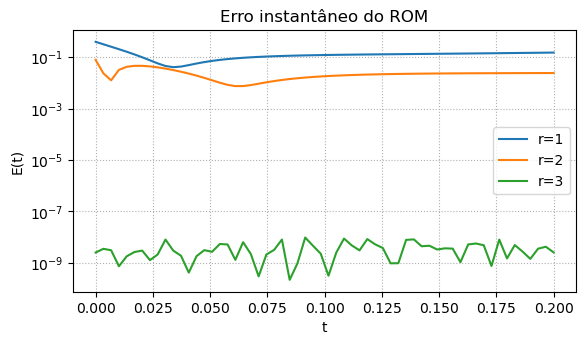

In [11]:
# Erro instantâneo E(t) para alguns r.
fig, ax = plt.subplots(figsize=(6.5, 3.4))
for r in [1, 2, 3]:
    U_rom = roda_rom(r)
    # axis=0 calcula a norma de CADA COLUNA separadamente: como cada coluna é o estado
    # num instante, Et fica sendo o erro relativo a cada t (um vetor com len(t) valores).
    # O + 1e-30 no denominador evita divisão por zero caso algum ||u(t)|| seja ~ 0.
    Et = np.linalg.norm(U_full - U_rom, axis=0) / (np.linalg.norm(U_full, axis=0) + 1e-30)
    ax.semilogy(t, Et + 1e-16, label=f"r={r}")   # +1e-16 só para a escala log não receber 0
ax.set_xlabel("t"); ax.set_ylabel("E(t)"); ax.legend(); ax.grid(True, ls=":")
ax.set_title("Erro instantâneo do ROM"); plt.show()

## 10. Consolidação do Módulo 1: SVD → PCA → POD → ROM

| Ferramenta | Objeto principal | Interpretação |
|---|---|---|
| **SVD** | matriz qualquer $X$ | direções ortogonais ponderadas por valores singulares |
| **SVD truncada** | aproximação $X_r$ | melhor posto $r$ (Eckart–Young) |
| **PCA** | dados centrados | direções de máxima variância (redução estatística) |
| **POD** | snapshots de campos | modos espaciais + coeficientes temporais |
| **ROM** | dinâmica reduzida | equações para os coeficientes no subespaço |

$$\text{dados de alta dimensão}\ \xrightarrow{\text{SVD/POD}}\ \text{modos dominantes}\ \xrightarrow{\text{projeção}}\ \text{dinâmica reduzida}.$$

A passagem de SVD para PCA/POD é mudança de **interpretação**; de POD para ROM é mudança de
**natureza** (de decomposição de dados para aproximação de dinâmica).

## Síntese da aula

- Um **ROM** aproxima o estado por $\mathbf{u}\approx\Phi\mathbf{a}$ (geometria) e a dinâmica por
  $\dot{\mathbf{a}}=\Phi^T\mathbf{F}(\Phi\mathbf{a})$ (evolução). No caso linear, $A_r=\Phi^TA\Phi$.
- A **projeção de Galerkin** impõe resíduo ortogonal ao subespaço; o erro de projeção é o limite
  inferior, e o ROM adiciona o erro da dinâmica reduzida.
- **POD ≠ ROM**: a POD dá a base ótima de reconstrução; o ROM dá a dinâmica — e precisa de
  **validação**.

## Limitações a discutir

- O subespaço POD pode **não** ser invariante pela dinâmica → ROM é aproximação; valide sempre.
- Em sistemas **não lineares/instáveis**, modos descartados podem alimentar os retidos.
- O termo não linear pode manter custo $O(n)$ (DEIM/EIM/gappy POD como horizonte).
- **Energia ≠ importância dinâmica**: um modo fraco pode reger estabilidade/transição.
- Erro global pequeno pode esconder erro grande numa **grandeza física** de interesse.

## Experimentos sugeridos

1. Refaça os Exercícios 2 e 3 (operador reduzido com bases diferentes).
2. Varie $r$ no ROM do calor e observe erro/estabilidade.
3. Use uma condição inicial que excite modos rápidos e veja o ROM errar no transiente (Ex.4).
4. Exercício 6 ($\sigma=(10,4,1,0.5)$): truncagem para compressão vs ROM.

*Fim do Módulo 1. A partir da Aula 9, começamos **regressão e mínimos quadrados** — o caminho para
modelos preditivos a partir de dados.*